<a href="https://colab.research.google.com/github/unatardedemartes-a11y/ClassFiles/blob/main/D6_Optimizacion_Numerica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualización 1 — SGD vs GD (convergencia oscilante)

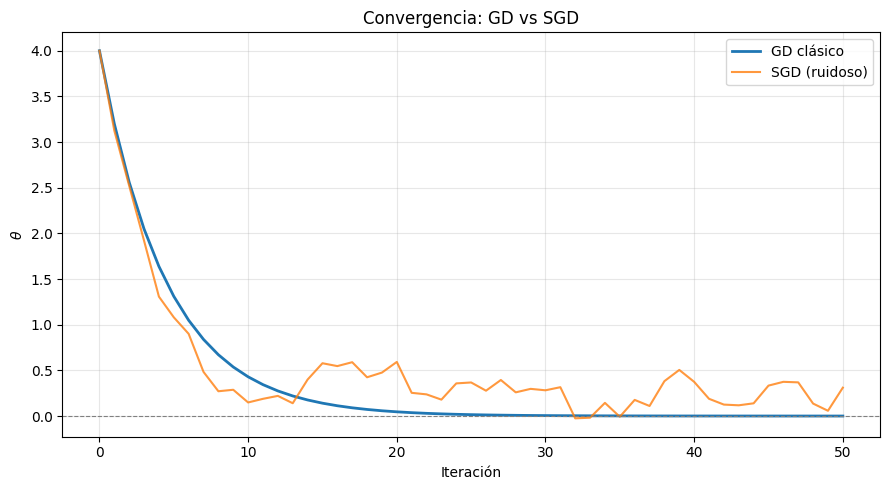

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Función objetivo: parábola simple
def J(theta):
    return theta**2

def grad(theta):
    return 2*theta

# GD clásico
theta_gd = 4.0
alpha = 0.1
hist_gd = [theta_gd]
for _ in range(50):
    theta_gd -= alpha * grad(theta_gd)
    hist_gd.append(theta_gd)

# SGD con ruido
theta_sgd = 4.0
hist_sgd = [theta_sgd]
for _ in range(50):
    noise = np.random.normal(0, 1.5)
    theta_sgd -= alpha * (grad(theta_sgd) + noise)
    hist_sgd.append(theta_sgd)

plt.figure(figsize=(9, 5))
plt.plot(hist_gd, label='GD clásico', linewidth=2, color='#1f77b4')
plt.plot(hist_sgd, label='SGD (ruidoso)', linewidth=1.5,
         color='#ff7f0e', alpha=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('Iteración')
plt.ylabel(r'$\theta$')
plt.title('Convergencia: GD vs SGD')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('viz1_sgd_vs_gd.png', dpi=200, bbox_inches='tight')
plt.show()

# Visualización 2 — Momentum vs SGD (bola rodando)

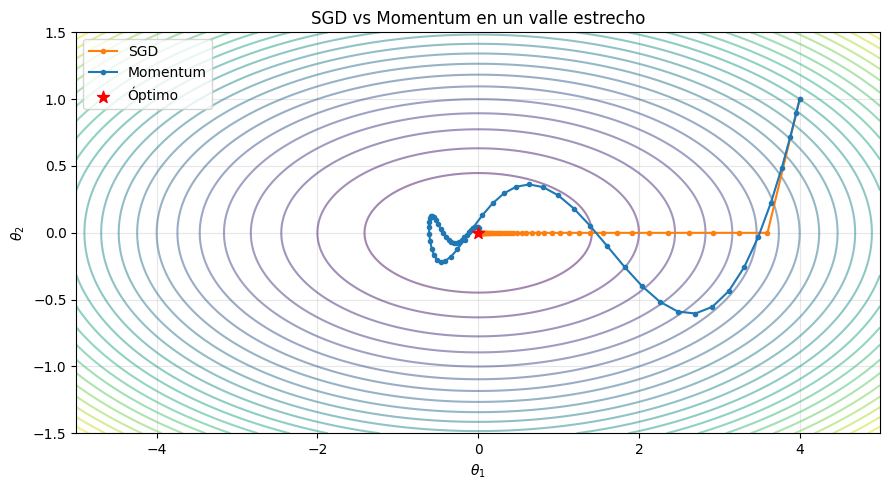

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

def J(theta):
    return theta[0]**2 + 10*theta[1]**2   # valle estrecho

def grad(theta):
    return np.array([2*theta[0], 20*theta[1]])

# SGD puro
theta = np.array([4.0, 1.0])
alpha = 0.05
path_sgd = [theta.copy()]
for _ in range(60):
    theta = theta - alpha * grad(theta)
    path_sgd.append(theta.copy())
path_sgd = np.array(path_sgd)

# Momentum
theta = np.array([4.0, 1.0])
v = np.zeros(2)
beta = 0.9
path_mom = [theta.copy()]
for _ in range(60):
    v = beta*v + (1-beta)*grad(theta)
    theta = theta - alpha * v
    path_mom.append(theta.copy())
path_mom = np.array(path_mom)

# Curvas de nivel
x = np.linspace(-5, 5, 200)
y = np.linspace(-1.5, 1.5, 200)
X, Y = np.meshgrid(x, y)
Z = X**2 + 10*Y**2

plt.figure(figsize=(9, 5))
plt.contour(X, Y, Z, levels=25, cmap='viridis', alpha=0.5)
plt.plot(path_sgd[:,0], path_sgd[:,1], 'o-',
         label='SGD', color='#ff7f0e', markersize=3)
plt.plot(path_mom[:,0], path_mom[:,1], 'o-',
         label='Momentum', color='#1f77b4', markersize=3)
plt.scatter([0], [0], color='red', s=80, marker='*', zorder=5,
            label='Óptimo')
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title('SGD vs Momentum en un valle estrecho')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('viz2_momentum.png', dpi=200, bbox_inches='tight')
plt.show()

# Visualización 3 — PCA (reducción de dimensionalidad)

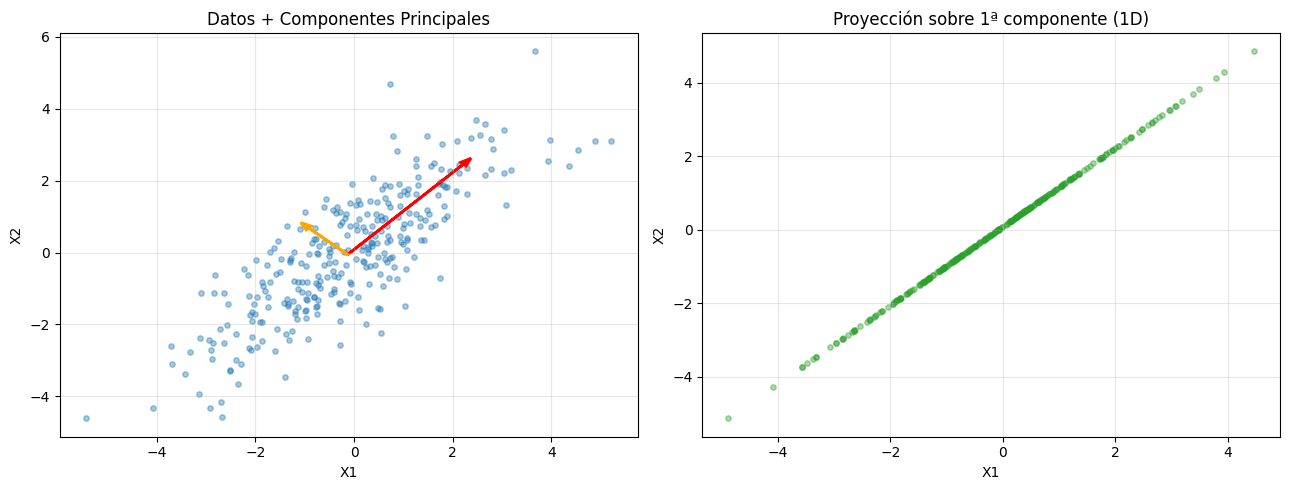

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# Datos sintéticos correlacionados
mean = [0, 0]
cov = [[3, 2.5], [2.5, 3]]
X = np.random.multivariate_normal(mean, cov, 300)

# PCA manual
X_centered = X - X.mean(axis=0)
cov_matrix = np.cov(X_centered.T)
eigvals, eigvecs = np.linalg.eigh(cov_matrix)
idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, idx]
eigvals = eigvals[idx]

# Proyección sobre la primera componente
proj = X_centered @ eigvecs[:, 0:1] @ eigvecs[:, 0:1].T + X.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: datos + componentes
axes[0].scatter(X[:,0], X[:,1], alpha=0.4, s=15, color='#1f77b4')
origin = X.mean(axis=0)
for i, (val, vec) in enumerate(zip(eigvals, eigvecs.T)):
    axes[0].arrow(origin[0], origin[1],
                  vec[0]*np.sqrt(val)*1.5, vec[1]*np.sqrt(val)*1.5,
                  head_width=0.15, color='red' if i==0 else 'orange',
                  linewidth=2)
axes[0].set_title('Datos + Componentes Principales')
axes[0].set_xlabel('X1'); axes[0].set_ylabel('X2')
axes[0].grid(alpha=0.3)

# Panel 2: proyección 1D
axes[1].scatter(proj[:,0], proj[:,1], alpha=0.4, s=15, color='#2ca02c')
axes[1].set_title('Proyección sobre 1ª componente (1D)')
axes[1].set_xlabel('X1'); axes[1].set_ylabel('X2')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('viz3_pca.png', dpi=200, bbox_inches='tight')
plt.show()

# Visualización 4 — Programación Lineal (región factible + trayectoria)

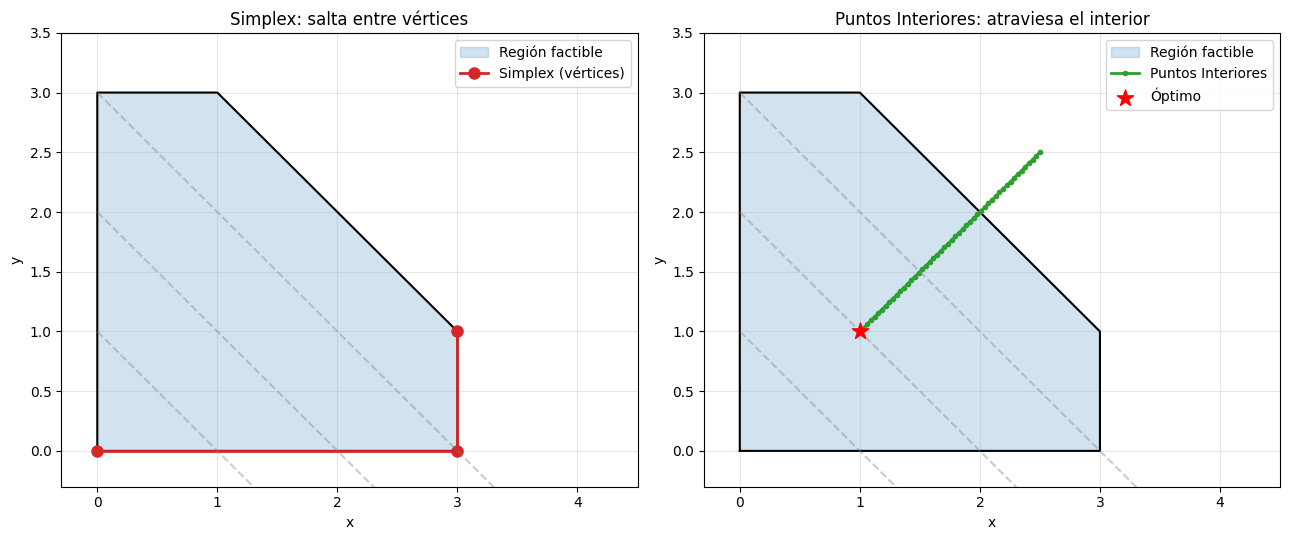

In [4]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Región factible: x+y <= 4, x <= 3, y <= 3, x,y >= 0
x = np.linspace(0, 4.5, 400)

# Restricciones
y1 = 4 - x          # x + y <= 4
y2 = np.full_like(x, 3)  # y <= 3
y3 = np.full_like(x, 0)  # y >= 0

# Vértices del polígono factible
vertices = np.array([[0,0],[3,0],[3,1],[1,3],[0,3],[0,0]])

# Panel 1: Simplex (vértice a vértice)
ax = axes[0]
ax.fill(vertices[:,0], vertices[:,1], alpha=0.2, color='#1f77b4',
        label='Región factible')
ax.plot(vertices[:,0], vertices[:,1], 'k-', linewidth=1.5)
# Trayectoria Simplex
simplex_path = np.array([[0,0],[3,0],[3,1]])
ax.plot(simplex_path[:,0], simplex_path[:,1], 'o-',
        color='#d62728', linewidth=2, markersize=8,
        label='Simplex (vértices)')
# Curva de nivel del objetivo
for c in [1, 2, 3]:
    ax.plot(x, c - x, '--', color='gray', alpha=0.4)
ax.set_xlim(-0.3, 4.5); ax.set_ylim(-0.3, 3.5)
ax.set_title('Simplex: salta entre vértices')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); ax.grid(alpha=0.3)

# Panel 2: Puntos Interiores (trayectoria curva)
ax = axes[1]
ax.fill(vertices[:,0], vertices[:,1], alpha=0.2, color='#1f77b4',
        label='Región factible')
ax.plot(vertices[:,0], vertices[:,1], 'k-', linewidth=1.5)
# Trayectoria curva simulada
t = np.linspace(0, 1, 50)
interior_path_x = 2.5 - 1.5*t
interior_path_y = 2.5 - 1.5*t
ax.plot(interior_path_x, interior_path_y, 'o-',
        color='#2ca02c', linewidth=2, markersize=3,
        label='Puntos Interiores')
ax.scatter([1], [1], color='red', s=150, marker='*',
           zorder=5, label='Óptimo')
for c in [1, 2, 3]:
    ax.plot(x, c - x, '--', color='gray', alpha=0.4)
ax.set_xlim(-0.3, 4.5); ax.set_ylim(-0.3, 3.5)
ax.set_title('Puntos Interiores: atraviesa el interior')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('viz4_pl.png', dpi=200, bbox_inches='tight')
plt.show()